# 01 — Data Retrieval from Allen Brain Observatory

## Purpose
Download raw Neuropixels LFP recordings and stimulus tables for the
Visual Coding dataset from the Allen Brain Observatory using the `allensdk`.

## Prerequisites
- `allensdk` installed (`pip install allensdk`)
- Sufficient disk space (~several GB per session)
- Writable output directory (set `output_dir` in the first code cell)

## What this notebook does
1. Queries the Allen Brain Observatory session table (Visual Coding — Neuropixels)
2. Filters for wildtype (WT) mouse sessions
3. Downloads session data and LFP recordings for each session
4. Extracts LFP time series from probe C (targeting primary visual cortex, VISp)
5. Aligns LFP snippets to stimulus presentation windows (1-second trials)
6. Saves per-session trial arrays to disk:
   - `lfp_trials_{session_id}_probeC.npy`    — shape (N_trials, N_channels, N_samples)
   - `stim_labels_{session_id}_probeC.npy`   — shape (N_trials,)
   - `lfp_trials_{session_id}_spontaneous.npy`
   - `stim_labels_{session_id}_spontaneous.npy`

## ⚠️ Note on paths
All `output_dir` variables in the cells below point to the original HPC path.
Change them to your local data directory before running.

In [1]:
import os
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio #might not be needed but w/e
%matplotlib inline

from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from allensdk.brain_observatory.ecephys.visualization import raster_plot


In [2]:
output_dir = '/projectnb/cs523aw/students/pangelos/RetreivedData/'
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
print(cache.get_all_session_types())

['brain_observatory_1.1', 'functional_connectivity']


In [3]:
cache.get_session_table().head()

,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


In [4]:
sessions = cache.get_session_table()
wt_sessions = sessions[(sessions.session_type == "functional_connectivity") & \
                          (sessions.full_genotype.str.find('wt/wt') > -1)]
wt_sessions
wt_sessions.index

Int64Index([766640955, 767871931, 768515987, 771160300, 771990200, 774875821,
            778240327, 778998620, 779839471, 781842082, 793224716, 819186360,
            821695405, 847657808],
           dtype='int64', name='id')

In [5]:
# Download data for all WT sessions
for session_id in wt_sessions.index:
    session = cache.get_session_data(session_id)

/usr4/cs523aw/pangelos/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/usr4/cs523aw/pangelos/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/usr4/cs523aw/pangelos/.local/lib/python

In [6]:
session_row = wt_sessions.loc[session_id]
animal_id = session_row['specimen_id']
animal_id

827809884

In [7]:
probes = cache.get_probes()
print('Total number of probes: ' + str(len(probes)))
session_probes = probes[probes["ecephys_session_id"] == session_id]
print("Number of probes in session:", len(session_probes))
print(session_probes.columns)

Total number of probes: 332
Number of probes in session: 6
Index(['ecephys_session_id', 'lfp_sampling_rate', 'name', 'phase',
       'sampling_rate', 'has_lfp_data', 'unit_count', 'channel_count',
       'ecephys_structure_acronyms'],
      dtype='object')


In [8]:
units = cache.get_units()
print('Total number of units: ' + str(len(units)))
session_units = units[units["ecephys_session_id"] == session_id]
print('Number of units in session: ' + str(len(session_units)))

Total number of units: 40010
Number of units in session: 874


In [9]:
session.get_stimulus_epochs()

/usr4/cs523aw/pangelos/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


,start_time,stop_time,duration,stimulus_name,stimulus_block
0,8.596360,68.663000,60.066640,spontaneous,null
1,68.663000,980.653410,911.990410,gabors,0.0
2,980.653410,1269.643450,288.990040,spontaneous,null
3,1269.643450,1568.141415,298.497965,flashes,1.0
4,1568.141415,1629.942720,61.801305,spontaneous,null
5,1629.942720,2169.891265,539.948545,drifting_gratings_contrast,2.0
6,2169.891265,2290.491440,120.600175,spontaneous,null
7,2290.491440,3191.239730,900.748290,natural_movie_one_more_repeats,3.0
8,3191.239730,3491.489150,300.249420,natural_movie_one_shuffled,4.0
9,3491.489150,4391.236581,899.747431,drifting_gratings_75_repeats,5.0


In [ ]:
# session.get_stimulus_table(['gabors'])
# session.get_stimulus_table(['drifting_gratings_75_repeats'])
# session.get_stimulus_table(['natural_movie_one_shuffled'])
# session.get_stimulus_table(['natural_movie_one_more_repeats'])
# session.get_stimulus_table(['dot_motion'])
# session.get_stimulus_table(['spontaneous'])
# session.get_stimulus_table(['flashes'])

In [ ]:
dg_presentations = session.stimulus_presentations.loc[
    # session.stimulus_presentations['stimulus_name'] == 'drifting_gratings_75_repeats'
    # session.stimulus_presentations['stimulus_block'] == 5.0
     session.stimulus_presentations['stimulus_block'] == 6.0
    #session.stimulus_presentations['stimulus_block'] == 2.0
    # session.stimulus_presentations.index == 40639
]

# Overall start and end of the stimulus block
start_time = dg_presentations['start_time'].min()
end_time = dg_presentations['stop_time'].max()

dg_presentations

In [ ]:
# window_length = 2  # seconds
# n_target = 1000

# for session_id in wt_sessions.index:
#     out_file = os.path.join(output_dir, f"lfp_trials_{session_id}_spontaneous.npy")
#     labels_out_file = os.path.join(output_dir, f"stim_labels_{session_id}_spontaneous.npy")
#     if os.path.exists(out_file):
#         print(f"Session {session_id}: spontaneous windows already extracted, skipping.")
#         continue

#     print(f"Processing session {session_id}: extracting spontaneous windows...")
#     session = cache.get_session_data(session_id)
#     session_probes = probes[probes["ecephys_session_id"] == session_id]
#     probe_c_row = session_probes[session_probes["name"] == "probeC"]
#     if not probe_c_row.empty and 'VISp' in probe_c_row.iloc[0]["ecephys_structure_acronyms"]:
#         probe_c_id = probe_c_row.index[0]
#         lfp_c = session.get_lfp(probe_c_id)
#         sample_rate = session.probes.loc[probe_c_id]['lfp_sampling_rate']
#         n_samples = int(window_length * sample_rate)
#         trial_offsets = np.arange(n_samples) / sample_rate

#         presentation_table = session.stimulus_presentations
#         spontaneous_rows = presentation_table[presentation_table.stimulus_name == "spontaneous"]

#         # Collect all possible window start times
#         all_window_tuples = []
#         for _, row in spontaneous_rows.iterrows():
#             block_start = row.start_time
#             block_end = row.stop_time
#             n_windows = int((block_end - block_start) // window_length)
#             for i in range(n_windows):
#                 t = block_start + i * window_length
#                 all_window_tuples.append(t)

#         # Randomly sample up to n_target windows per session
#         if len(all_window_tuples) > n_target:
#             rng = np.random.default_rng(seed=42)
#             sampled_times = rng.choice(all_window_tuples, size=n_target, replace=False)
#         else:
#             sampled_times = all_window_tuples

#         aligned_lfp_list = []
#         for t in sampled_times:
#             window_times = t + trial_offsets
#             lfp_win = lfp_c.sel(time=window_times, method='nearest').values.astype('float32')
#             aligned_lfp_list.append(lfp_win)
#         labels_list = ['spontaneous'] * len(aligned_lfp_list)

#         if len(aligned_lfp_list) > 0:
#             lfp_trials = np.stack(aligned_lfp_list, axis=0)
#             lfp_trials = np.transpose(lfp_trials, (0,2,1))
#             np.save(out_file, lfp_trials)
#             np.save(labels_out_file, np.array(labels_list))
#             print(f"Session {session_id}: extracted {lfp_trials.shape[0]} spontaneous windows (downsampled).")
#         else:
#             print(f"Session {session_id}: no spontaneous periods found.")
#     else:
#         print(f"Session {session_id}: probeC missing or does not contain VISp, skipping.")

In [ ]:
# #NEW LFP COLLECTION BLOCK
# #"probeC" associated with VISp for the current session
# for session_id in wt_sessions.index:
#     print(f"Processing session {session_id}...")
#     session = cache.get_session_data(session_id)
#     session_probes = probes[probes["ecephys_session_id"] == session_id]

#     # Select probeC for this session
#     probe_c_row = session_probes[session_probes["name"] == "probeC"]

#     if not probe_c_row.empty and 'VISp' in probe_c_row.iloc[0]["ecephys_structure_acronyms"]:
#         probe_c_id = probe_c_row.index[0]
#         print(f"Session {session_id}: probeC found with VISp, extracting LFP...")
#         lfp_c = session.get_lfp(probe_c_id)
#         np.save(os.path.join(output_dir, f"lfp_{session_id}_probeC.npy"), lfp_c.data)
#         print(f"Session {session_id}: LFP data saved, shape: {lfp_c.data.shape}")
#     else:
#         print(f"Session {session_id}: probeC missing or does not contain VISp, skipping.")


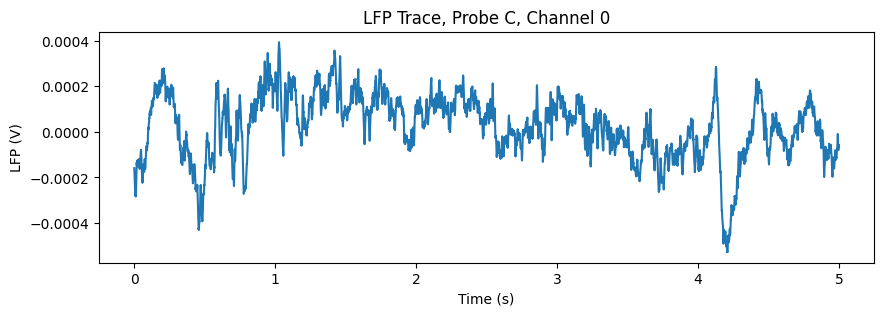

In [10]:
# Load the LFP data previously saved
lfp = np.load(os.path.join(output_dir, f"lfp_{session_id}_probeC.npy"))

# Define variables
sample_rate = 1250  # Hz, typical for AllenSDK LFPs
seconds_to_plot = 5
samples_to_plot = seconds_to_plot * sample_rate

plt.figure(figsize=(10, 3))
# Plot first channel (column 0) for the first N timepoints (rows)
plt.plot(np.arange(samples_to_plot) / sample_rate, lfp[:samples_to_plot, 0])
plt.xlabel("Time (s)")
plt.ylabel("LFP (V)")
plt.title("LFP Trace, Probe C, Channel 0")
plt.show()


In [11]:
print(lfp.shape)

(12300247, 68)


Session 766640955: output file already exists, skipping re-extraction.
Session 767871931: output file already exists, skipping re-extraction.
Session 768515987: output file already exists, skipping re-extraction.
Session 771160300: output file already exists, skipping re-extraction.
Session 771990200: output file already exists, skipping re-extraction.
Session 774875821: output file already exists, skipping re-extraction.
Session 778240327: output file already exists, skipping re-extraction.
Processing session 778998620...
Session 778998620: probeC found with VISp, extracting LFP...
Session 778998620: LFP data extracted and shaped (154710, 89, 1249)
Label counts BEFORE subsampling:
 spontaneous                       77355
natural_movie_one_more_repeats    54000
natural_movie_one_shuffled        18000
gabors                             3645
drifting_gratings_75_repeats        600
drifting_gratings_contrast          540
dot_motion                          420
flashes                     

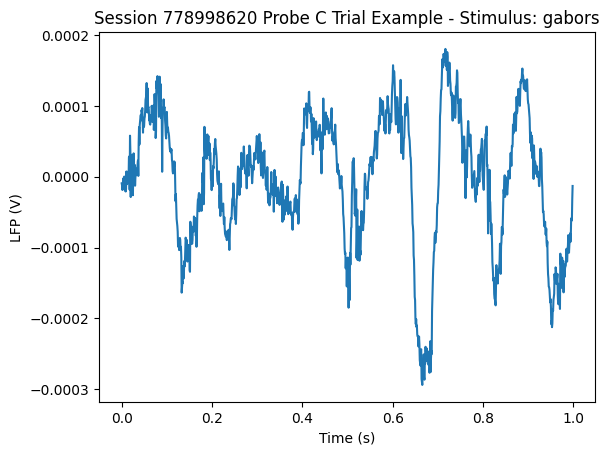

Processing session 779839471...
Session 779839471: probeC found with VISp, extracting LFP...


In [ ]:
window_length = 1.0  # seconds for each trial window

for session_id in wt_sessions.index:
    out_file = os.path.join(output_dir, f"lfp_trials_{session_id}_probeC.npy")
    labels_out_file = os.path.join(output_dir, f"stim_labels_{session_id}_probeC.npy")
    
    if os.path.exists(out_file):
        print(f"Session {session_id}: output file already exists, skipping re-extraction.")
        continue  # Skip this session
    
    print(f"Processing session {session_id}...")
    session = cache.get_session_data(session_id)
    session_probes = probes[probes["ecephys_session_id"] == session_id]

    # Select probeC for this session
    probe_c_row = session_probes[session_probes["name"] == "probeC"]

    if not probe_c_row.empty and 'VISp' in probe_c_row.iloc[0]["ecephys_structure_acronyms"]:
        probe_c_id = probe_c_row.index[0]
        print(f"Session {session_id}: probeC found with VISp, extracting LFP...")
        lfp_c = session.get_lfp(probe_c_id)  # xarray DataArray: time x channel
        sample_rate = session.probes.loc[probe_c_id]['lfp_sampling_rate']
        n_samples = int(window_length * sample_rate)
        trial_offsets = np.arange(n_samples) / sample_rate  # relative times in seconds

        # Full stimulus presentation table
        presentation_table = session.stimulus_presentations

        # 1) Evoked trials (non-spontaneous)
        evoked_mask = presentation_table.stimulus_name != "spontaneous"
        evoked_rows = presentation_table[evoked_mask]

        evoked_start_times = evoked_rows.start_time.values
        evoked_labels = evoked_rows.stimulus_name.values

        all_trials = []
        all_labels = []

        for t, label in zip(evoked_start_times, evoked_labels):
            window_times = t + trial_offsets  # onset-aligned window
            lfp_win = lfp_c.sel(time=window_times, method='nearest')  # (time, channel)
            trial = np.transpose(lfp_win.values, (1, 0))  # (channels, time)
            if np.isnan(trial).any():
                continue
            all_trials.append(trial)
            all_labels.append(label)

        # 2) Spontaneous trials: matched windows
        spont_mask = presentation_table.stimulus_name == "spontaneous"
        spont_rows = presentation_table[spont_mask]
        spont_blocks = list(zip(spont_rows.start_time.values,
                                spont_rows.stop_time.values))

        # Aim for similar number of spontaneous trials as total evoked
        n_spont_target = len(all_labels)
        rng = np.random.default_rng(seed=17)
        spont_trials_collected = 0
        max_attempts = n_spont_target * 5

        while spont_trials_collected < n_spont_target and max_attempts > 0 and len(spont_blocks) > 0:
            max_attempts -= 1
            block_start, block_stop = spont_blocks[rng.integers(0, len(spont_blocks))]

            # Ensure there is room for a full window with small margins
            margin = 0.1
            if block_stop - block_start <= window_length + 2 * margin:
                continue

            t0 = rng.uniform(block_start + margin, block_stop - margin - window_length)
            window_times = t0 + trial_offsets
            lfp_win = lfp_c.sel(time=window_times, method='nearest')
            trial = np.transpose(lfp_win.values, (1, 0))  # (channels, time)
            if np.isnan(trial).any():
                continue

            all_trials.append(trial)
            all_labels.append("spontaneous")
            spont_trials_collected += 1

        if len(all_trials) > 0:
            lfp_trials = np.stack(all_trials, axis=0)  # (N_trials, C, T)
            stim_labels = np.array(all_labels, dtype=object)

            print(f"Session {session_id}: LFP data extracted and shaped {lfp_trials.shape}")
            print("Label counts BEFORE subsampling:\n", pd.Series(stim_labels).value_counts())

            # 3) Subsample to limit per-class trials
            max_per_class = 3000  # adjust as desired

            labels_series = pd.Series(stim_labels)
            keep_indices = []
            rng = np.random.default_rng(seed=42)

            for label, idxs in labels_series.groupby(labels_series).groups.items():
                idxs = np.array(list(idxs))
                if len(idxs) > max_per_class:
                    idxs = rng.choice(idxs, size=max_per_class, replace=False)
                keep_indices.append(idxs)

            keep_indices = np.concatenate(keep_indices)
            rng.shuffle(keep_indices)

            lfp_trials = lfp_trials[keep_indices]
            stim_labels = stim_labels[keep_indices]

            print("After subsampling:")
            print("LFP shape:", lfp_trials.shape)
            print("Label counts:\n", pd.Series(stim_labels).value_counts())

            # Save the aligned LFP trials array
            np.save(out_file, lfp_trials)
            print(f"Session {session_id}: aligned LFP trials saved.")

            # Save corresponding stimulus labels
            np.save(labels_out_file, stim_labels)
            print(f"Session {session_id}: stimulus labels saved.")

            # Optional visualization example for first trial, first channel
            plt.figure()
            plt.plot(trial_offsets, lfp_trials[0, 0])
            plt.xlabel('Time (s)')
            plt.ylabel('LFP (V)')
            plt.title(f"Session {session_id} Probe C Trial Example - Stimulus: {stim_labels[0]}")
            plt.show()
        else:
            print(f"Session {session_id}: No valid trials found, skipping saving this file.")
    else:
        print(f"Session {session_id}: probeC missing or does not contain VISp, skipping.")


In [ ]:
# Identify "probeC" associated with VISp for the current session
probe_c_row = session_probes[session_probes["description"] == "probeC"]
if 'VISp' in probe_c_row.iloc[0]["structure_acronyms"]:  # column may also be named 'ecephys_structure_acronyms'
    probe_c_id = probe_c_row.index[0]
    print(f"probeC (id={probe_c_id}) contains VISp. Extracting LFP data.")
    lfp_c = session.get_lfp(probe_c_id)
    np.save(os.path.join(output_dir, f"lfp_{session_id}_probeC.npy"), lfp_c.data)
    print("LFP data for probeC saved. Shape:", lfp_c.data.shape)
else:
    print("probeC does not contain VISp for this session.")


In [ ]:
channels_probe_c = session.channels[session.channels.probe_id == probe_c_id]
probe_c_channel_ids = list(channels_probe_c.index)
print(f"Number of channels in probe C: {len(probe_c_channel_ids)}")
print(f"Probe C channel IDs: {probe_c_channel_ids[:10]}...")  # print first 10 for sanity check
print(f"LFP shape: {lfp.shape}")



In [ ]:
channels_visp = channels_probe_c[channels_probe_c.ecephys_structure_acronym == 'VISp']
visp_ids = list(channels_visp.index)
print(f"Number of VISp channels on probe C: {len(visp_ids)}")
print(f"VISp channel IDs: {visp_ids[:10]}...")

# Check which VISp IDs are missing in Probe C channels
missing_ids = [ch for ch in visp_ids if ch not in probe_c_channel_ids]
print(f"VISp ids missing in probe C channels: {missing_ids}")


In [ ]:
valid_visp_ids = [ch for ch in visp_ids if ch in probe_c_channel_ids]
local_visp_indices = [probe_c_channel_ids.index(ch) for ch in valid_visp_ids]
print(f"Local VISp channel indices: {local_visp_indices}")


In [ ]:
lfp = session.get_lfp(probe_c_id)
print(lfp)

In [ ]:
lfp_channel_ids = lfp.coords['channel'].values
print(len(lfp_channel_ids), lfp_channel_ids[:10])

In [ ]:
channels_probe_c = session.channels[session.channels.probe_id == probe_c_id]
channels_visp = channels_probe_c[channels_probe_c.ecephys_structure_acronym == 'VISp']
visp_ids = channels_visp.index.values


In [ ]:
visp_indices_in_lfp = [i for i, ch_id in enumerate(lfp_channel_ids) if ch_id in visp_ids]


In [ ]:
lfp_visp = lfp[:, visp_indices_in_lfp]
plt.figure(figsize=(10, 6))
plt.imshow(lfp_visp.T, aspect='auto', origin='lower', vmin=-1e-3, vmax=1e-3)
plt.colorbar(label='LFP (V)')
plt.xlabel('Time samples')
plt.ylabel('VISp Channels')
plt.title('LFP Heatmap: VISp Channels on Probe C')
plt.show()

In [ ]:
probe_id = probe_c_id

#Get the probes DataFrame and locate the row for your probe
probes_df = session.probes  
lfp_sampling_rate = probes_df.loc[probe_id]['lfp_sampling_rate']

print(f"LFP sampling rate for probe {probe_id}: {lfp_sampling_rate} Hz")


In [ ]:
# window_length = 2  # seconds

# for session_id in wt_sessions.index:
#     out_file = os.path.join(output_dir, f"lfp_trials_{session_id}_probeC.npy")
#     labels_out_file = os.path.join(output_dir, f"stim_labels_{session_id}_probeC.npy")
    
#     if os.path.exists(out_file):
#         print(f"Session {session_id}: output file already exists, skipping re-extraction.")
#         continue  # Skip this session, do not redo
    
#     print(f"Processing session {session_id}...")
#     session = cache.get_session_data(session_id)
#     session_probes = probes[probes["ecephys_session_id"] == session_id]

#     # Select probeC for this session
#     probe_c_row = session_probes[session_probes["name"] == "probeC"]

#     if not probe_c_row.empty and 'VISp' in probe_c_row.iloc[0]["ecephys_structure_acronyms"]:
#         probe_c_id = probe_c_row.index[0]
#         print(f"Session {session_id}: probeC found with VISp, extracting LFP...")
#         lfp_c = session.get_lfp(probe_c_id)

#         # Get sampling rate
#         sample_rate = session.probes.loc[probe_c_id]['lfp_sampling_rate']
#         n_samples = int(window_length * sample_rate)
#         trial_offsets = np.arange(n_samples) / sample_rate

#         # Get stimulus presentation info
#         presentation_table = session.stimulus_presentations

#         # Only include non-spontaneous stimuli
#         mask = presentation_table.stimulus_name != "spontaneous"
#         stim_rows = presentation_table[mask]

#         presentation_times = stim_rows.start_time.values
#         stim_labels = stim_rows.stimulus_name.values

#         # Extract aligned LFP windows
#         aligned_lfp_list = []
#         for t in presentation_times:
#             window_times = t + trial_offsets
#             lfp_win = lfp_c.sel(time=window_times, method='nearest')
#             aligned_lfp_list.append(lfp_win.values)

#         if len(aligned_lfp_list) > 0:
#             lfp_trials = np.stack(aligned_lfp_list, axis=0)
#             lfp_trials = np.transpose(lfp_trials, (0,2,1))  # prepare for GRU input

#             print(f"Session {session_id}: LFP data extracted and shaped {lfp_trials.shape}")

#             # Save the aligned LFP trials array
#             np.save(out_file, lfp_trials)
#             print(f"Session {session_id}: aligned LFP trials saved.")

#             # Save corresponding stimulus labels
#             np.save(labels_out_file, stim_labels)
#             print(f"Session {session_id}: stimulus labels saved.")

#             # Optional visualization example for first trial, first channel
#             plt.plot(trial_offsets, lfp_trials[0, 0])
#             plt.xlabel('Time (s)')
#             plt.ylabel('LFP (V)')
#             plt.title(f"Session {session_id} Probe C Trial Example - Stimulus: {stim_labels[0]}")
#             plt.show()
#         else:
#             print(f"Session {session_id}: No non-spontaneous stimuli found, skipping saving this file.")
#     else:
#         print(f"Session {session_id}: probeC missing or does not contain VISp, skipping.")


In [ ]:
# # Raster plot
# times = session.presentationwise_spike_times(
#    stimulus_presentation_ids=dg_presentations.index.values
# )

# times.head()

In [ ]:
# times['stimulus_presentation_id'].values

In [ ]:
# first_drifting_grating_presentation_id = times['stimulus_presentation_id'].values[0]
# plot_times = times[times['stimulus_presentation_id'] == first_drifting_grating_presentation_id]

# fig = raster_plot(plot_times, title=f'spike raster for stimulus presentation {first_drifting_grating_presentation_id}')
# plt.show()

In [ ]:
# # LESS INTERESTED IN THIS DATA SKIP TO LFP
# # Get spikes within that interval
# spikes_dict = session.spike_times
# unit_spike_times = {}
# for unit_id in session.units.index:
#     spikes = spikes_dict[unit_id]
#     spikes = spikes[(spikes >= start_time) & (spikes <= end_time)]
#     unit_spike_times[unit_id] = spikes

In [ ]:
# # Create session folder
# session_folder = os.path.join(output_dir, 'spontaneous', f"R{animal_id}", f"R{animal_id}-S{session_id}")
# os.makedirs(session_folder, exist_ok=True)
## BLOCK 74


In [ ]:
# # Get LFP data
# """for probe_id in session.probes.index:
#     probe_row = session.probes.loc[probe_id]       
#     probe_name = probe_row['description']
#     lfp = session.get_lfp(probe_id)  

#     # Filter by time interval 
#     lfp_interval = lfp[(lfp['time'] >= start_time) & (lfp['time'] <= end_time)]
    
#     # Save ALL channels - this takes too much time/memory, skipping
#     for ch in lfp.channel.values:
#         lfp_vector = lfp_interval.sel(channel=ch).values
#         lfp_filename = os.path.join(session_folder, f"R{animal_id}_S{session_id}_{probe_name}_ch{ch}.lfp")
#         np.savetxt(lfp_filename, lfp_vector, fmt='%.6f')"""

In [ ]:
# # Example - Check which LFP channels correspond to which brain structure for probe 1
# lfp = session.get_lfp(session.probes.index[0])  
# structure_acronyms, intervals = session.channel_structure_intervals(lfp["channel"])
# interval_midpoints = [aa + (bb - aa) / 2 for aa, bb in zip(intervals[:-1], intervals[1:])]
# print(structure_acronyms)
# print(intervals)

In [ ]:
# # Example: Get channels for a given structure
# probe_id = session.probes.index[0]
# hipp_ids = session.channels[(session.channels.probe_id == probe_id) & \
#                  (session.channels.ecephys_structure_acronym.isin(['CA1','CA3','DG']))].index.values
# hipp_ids

In [ ]:
LFPoutput_dir = '/projectnb/cs523aw/students/pangelos/RetreivedData/session_folder/'

In [ ]:
manifest_path = os.path.join(LFPoutput_dir, "manifest.json")

cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

In [ ]:
# Getting LFP data: 3 channels per brain structure, Probe C, VISP only.
probe_id = session.probes[session.probes.description == 'probeC'].index.values[0]
lfp = session.get_lfp(probe_id)

# channels = session.get_channels()
# probe_channels = channels[channels.probe_id == probe_id]

# visp_channels = probe_channels[probe_channels.structure_acronym == 'VISp']
# visp_local_ids = visp_channels.local_channel_id.values

# lfp_data_array = session.get_lfp(probe_id).data  # This loads the full LFP (Time x All Channels)
# visp_lfp_data = lfp_data_array[:, visp_local_ids]

In [ ]:
presentation_table = session.stimulus_presentations[session.stimulus_presentations.stimulus_name == 'flashes']

presentation_times = presentation_table.start_time.values
presentation_ids = presentation_table.index.values

In [ ]:
#aligning the vectors of the stimulus and LFP data
#Get the continuous time axis of the LFP data
lfp_time_stamps = lfp.time.values
#Initialize the target vector to all zeros
target_vector = np.zeros(lfp_time_stamps.shape[0], dtype=int)

In [ ]:
# Assuming 'session' and 'stim_table' are loaded
stim_table = session.stimulus_presentations 

# Get unique stimulus names, including the 'omitted' or 'gap' state
unique_names = stim_table['stimulus_name'].unique()
# Add a unique ID for the 'Grey' state (0)

# Create the mapping dictionary
stimulus_id_map = {name: i + 1 for i, name in enumerate(unique_names)}
stimulus_id_map[np.nan] = 0  # Treat NaNs as ID 0 (No Stimulus)

print("Stimulus ID Mapping:")
print(stimulus_id_map)

In [ ]:
#Iterate through every single presentation event
for row in stim_table.itertuples():
    
    onset_time = row.start_time
    duration = row.duration
    stimulus_name = row.stimulus_name
    
    #Calculate the offset time
    offset_time = onset_time + duration
    
    #Get the unique integer ID for this specific stimulus
    stim_id = stimulus_id_map.get(stimulus_name)
    
    #Skip if the stimulus name wasn't properly mapped (shouldn't happen with the first step)
    if stim_id is None:
        continue
    
    #Find the LFP indices corresponding to the onset and offset
    onset_index = np.searchsorted(lfp_time_stamps, onset_time)
    offset_index = np.searchsorted(lfp_time_stamps, offset_time)
    
    #Label the LFP samples with the specific categorical ID
    #This overwrites the initial 0s for the exact duration of the stimulus
    target_vector[onset_index:offset_index] = stim_id 

print(f"\nMulti-class target vector created.")
print(f"Length: {len(target_vector)}")
print(f"Number of unique classes in target: {len(np.unique(target_vector))}")

In [ ]:
reverse_map = {v: k for k, v in stimulus_id_map.items()}

#Count the occurrences of each unique ID in the target vector
#np.unique() returns the unique values and their counts
unique_ids, counts = np.unique(target_vector, return_counts=True)
summary_data = []

for unique_id, count in zip(unique_ids, counts):
    stim_name = reverse_map.get(unique_id, 'UNKNOWN_ID')
    
    # Calculate the total duration in seconds (assuming LFP is 500 Hz, 1/500 = 0.002s per sample)
    sample_rate_s = 1 / 500.0 # Assuming the LFP sample rate is 500 Hz
    total_duration_s = count * sample_rate_s
    
    summary_data.append({
        'Stimulus Name': stim_name,
        'ID': unique_id,
        'Sample Count': count,
        'Total Duration (s)': f"{total_duration_s:,.2f}" 
    })
count_summary = pd.DataFrame(summary_data).set_index('ID')

print("\n--- Categorical Target Summary (Time Samples) ---")
print(count_summary)

In [ ]:
import h5py

WINDOW_SIZE = 1000
STEP_SIZE = 100

# --- INITIALIZATION ---
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
session_ids = cache.get_session_table().index.values

print(f"Starting pipeline for {len(session_ids)} sessions...")
print(f"Output directory set to: {output_dir}") # This should print the full absolute path

# --- MAIN PROCESSING LOOP ---
for session_id in session_ids:
    
    print(f"\n--- Processing Session ID: {session_id} ---")
    
    try:
        # 1. RETRIEVE SESSION METADATA
        session = cache.get_session_data(session_id)
        
        probe_filter = session.probes.description == 'probeC'
        if not probe_filter.any():
            print("  -> SKIPPING: Probe C not found.")
            continue
            
        probe_id = session.probes[probe_filter].index.values[0]
        probe_name = session.probes.loc[probe_id, 'description']
        nwb_path = session.get_nwb_path()
        
        # 2. EFFICIENTLY LOAD VISp LFP DATA (Direct NWB Read)
        lfp_time_stamps = session.get_lfp_timestamps(probe_id) 

        with h5py.File(nwb_path, 'r') as f:
            
            # 2.1 Read the electrode/channel data from the NWB file (UTF-8 fix included)
            electrode_table = f['general/extracellular_ephys/electrodes']
            
            electrode_probe_name = electrode_table['probe_description'][()]
            electrode_structure = electrode_table['structure_acronym'][()]
            electrode_local_id = electrode_table['local_index'][()]

            probe_names = np.array([n.decode('utf-8', errors='ignore') for n in electrode_probe_name])
            structures = np.array([s.decode('utf-8', errors='ignore') for s in electrode_structure])

            probe_c_filter = (probe_names == probe_name)
            visp_filter = (structures == 'VISp')
            
            visp_local_ids = electrode_local_id[probe_c_filter & visp_filter]

            if len(visp_local_ids) == 0:
                print("  -> SKIPPING: VISp structure not found on Probe C.")
                continue

            # 2.2 Load LFP data
            lfp_data_dset = f[f'acquisition/lfp_{probe_name}/data']
            visp_lfp_data = lfp_data_dset[:, visp_local_ids]

        T, C = visp_lfp_data.shape
        print(f"  -> LFP data loaded. Shape: ({T}, {C})")
        
        # 3. GENERATE MULTI-CLASS TARGET VECTOR (Y)
        stim_table = session.stimulus_presentations
        unique_names = stim_table['stimulus_name'].unique()

        stimulus_id_map = {name: i + 1 for i, name in enumerate(unique_names)}
        stimulus_id_map['No_Stimulus_Baseline'] = 0 
        
        target_vector = np.zeros(lfp_time_stamps.shape[0], dtype=int)

        for row in stim_table.itertuples():
            onset_time = row.start_time
            duration = row.duration
            stimulus_name = row.stimulus_name
            offset_time = onset_time + duration
            
            stim_id = stimulus_id_map.get(stimulus_name)
            if stim_id is None: continue 
            
            onset_index = np.searchsorted(lfp_time_stamps, onset_time)
            
            # Corrected syntax: using offset_time
            offset_index = np.searchsorted(lfp_time_stamps, offset_time)
            
            target_vector[onset_index:offset_index] = stim_id 

        # 4. SEGMENT DATA INTO GRU SEQUENCES (X_train and Y_train)
        X_sequences = [] 
        Y_labels = []    
        
        if T < WINDOW_SIZE:
             print("  -> SKIPPING: Session too short for defined WINDOW_SIZE.")
             continue
             
        for start_index in range(0, T - WINDOW_SIZE + 1, STEP_SIZE):
            end_index = start_index + WINDOW_SIZE
            
            X_sequences.append(visp_lfp_data[start_index:end_index, :])
            
            Y_labels.append(target_vector[end_index - 1])

        X_train = np.array(X_sequences)
        Y_train = np.array(Y_labels)
        
        # 5. SAVE THE PROCESSED DATA
        # The file path is constructed here using the absolute path
        output_filepath = os.path.join(OUTPUT_DIR, f'session_{session_id}_sequences.npz')
        np.savez_compressed(
            output_filepath, 
            X_train=X_train, 
            Y_train=Y_train,
            stim_map=stimulus_id_map
        )

        print(f"  -> SUCCESS: Saved {X_train.shape[0]} sequences to {output_filepath}")

    except Exception as e:
        print(f"  -> ERROR processing session {session_id}: {e}")
        continue

In [ ]:
# output_filename = 'probeC_VISp_lfp_data.npy'
# np.save(output_filename, visp_lfp_data) 
# print(f"VISp LFP data saved to {output_filename}")

In [ ]:
# Get LFP data (only 3 channels per brain structure)
for session_id in wt_sessions.index:
# session_id = wt_sessions.index[13]
    session = cache.get_session_data(session_id)

    session_row = wt_sessions.loc[session_id]
    animal_id = session_row['specimen_id']

    session_folder = os.path.join(output_dir, f"R{stimulus_name}", f"R{animal_id}", f"R{animal_id}-S{session_id}")
    os.makedirs(session_folder, exist_ok=True)

# Select task condition
    dg_presentations = session.stimulus_presentations.loc[
    # session.stimulus_presentations['stimulus_name'] == 'drifting_gratings_75_repeats'
    # session.stimulus_presentations['stimulus_block'] == 6.0
#     session.stimulus_presentations.index == 40639
]

# Overall start and end of the stimulus block
    start_time = dg_presentations['start_time'].min()
    end_time = dg_presentations['stop_time'].max()

    for probe_id in session.probes.index:
        probe_row = session.probes.loc[probe_id]       
        probe_name = probe_row['description']

        # Skip all probes except probeC
        if probe_name != "probeC":
            continue

        print(f"\nProcessing {probe_name} (ID: {probe_id})...")

        lfp = session.get_lfp(probe_id)

        # Filter by time interval and keep only channels present in session.channels
        lfp_interval = lfp[(lfp['time'] >= start_time) & (lfp['time'] <= end_time)] 
        lfp_chs = [ch for ch in lfp_interval.channel.values if ch in session.channels.index]

        # Save time vector
        time_filename = os.path.join(session_folder, f"R{animal_id}_S{session_id}_{probe_name}-LfpTime.dat")
        if not os.path.exists(time_filename):
            lfp_interval.time.values.astype('float64').tofile(time_filename)
            print(f"Saved time vector to {time_filename}")
        else:
            print(f"Time vector file already exists: {time_filename}")

        # Identify brain structures per channel
        structure_acronyms, intervals = session.channel_structure_intervals(lfp_chs)

        # Map channels to structures
        ch_to_struct = {}
        for i, struct in enumerate(structure_acronyms):
            start = intervals[i]
            end = intervals[i+1]
            for ch_id in lfp_interval.channel.values[start:end]:
                if struct is not None and not (isinstance(struct, float) and np.isnan(struct)):
                    ch_to_struct.setdefault(struct, []).append(ch_id)

        # Check existing files
        structures_to_skip = set()
        for struct in ch_to_struct.keys():
            existing_files = glob.glob(os.path.join(session_folder, f"R{animal_id}_S{session_id}_{probe_name}_{struct}_ch*.lfp"))
            if len(existing_files) >= 3:
                print(f"Already have {len(existing_files)} channels for {struct}, skipping this structure entirely.")
                structures_to_skip.add(struct)

        # For each structure, pick 3 channels at random (or all if <3)
        for struct, channels in ch_to_struct.items():
            if struct in structures_to_skip:
                print(f"Structure {struct} already done. Skipping...")
                continue

            print(f"Structure: {struct}, {len(channels)} channels available")

            # Find already-saved LFPs for this structure in the session folder
            existing_files = glob.glob(os.path.join(session_folder, f"R{animal_id}_S{session_id}_{probe_name}_{struct}_ch*.lfp"))
            existing_ch_ids = [int(f.split("_ch")[-1].replace(".lfp", "")) for f in existing_files]

             # Remaining channels we could still save
            available_chs = [ch for ch in channels if ch not in existing_ch_ids]
            n_to_save = min(3 - len(existing_ch_ids), len(available_chs))

            if n_to_save == 0:
                print(f"No new channels available for {struct}")
                continue

            selected_channels = np.random.choice(available_chs, size=n_to_save, replace=False)

            for ch_id in selected_channels:
                base_filename = f"R{animal_id}_S{session_id}_{probe_name}_{struct}_ch{ch_id}"
                lfp_filename = os.path.join(session_folder, base_filename + ".lfp")

                # Skip if already exists 
                if os.path.exists(lfp_filename): 
                    print(f"Skipping existing file: {lfp_filename}") 
                    continue

                # Plot for quick quality check (optional) 
                # lfp_slice = lfp_interval.sel(time=slice(start_time,start_time+1))
                # plt.figure(figsize=(10,2))
                # _ = plt.plot(lfp_slice.time, lfp_slice.sel(channel=ch_id))
                # plt.xlabel('Time (s)')
                # plt.ylabel('LFP (V)')

                # Save LFP signal
                lfp_vector = lfp_interval.sel(channel=ch_id).values
                lfp_vector.astype('float32').tofile(lfp_filename)
                print(f"Saved LFP channel {ch_id} to {lfp_filename}")

In [ ]:
# # Move LFP files to structure folders
# for session_id in wt_sessions.index:
#     session = cache.get_session_data(session_id)
    
#     session_row = wt_sessions.loc[session_id]
#     animal_id = session_row['specimen_id']

#     session_folder = os.path.join(output_dir, 'spontaneous', f"R{animal_id}", f"R{animal_id}-S{session_id}")
    
#     for fname in os.listdir(session_folder):
#         if not fname.endswith(".lfp"):
#             continue

#         # Parse structure acronym from filename:
#         # Format: R{animal}_S{session}_{probe}_{struct}_ch{ch}.lfp
#         parts = fname.split("_")
#         if len(parts) < 4:
#             struct_name = "UNKNOWN"
#         else:
#             struct_name = parts[-2]  # the structure part

#         # Create structure subfolder if it doesn’t exist
#         struct_folder = os.path.join(session_folder, struct_name)
#         os.makedirs(struct_folder, exist_ok=True)

#         # Move file
#         src = os.path.join(session_folder, fname)
#         dst = os.path.join(struct_folder, fname)
#         shutil.move(src, dst)

#     print("All LFP files moved into structure-specific folders.")